# Notebook 03

# Extração de Características utilizando Amino Acid Linking (AAL)

No notebook anterior foi implementado o descritor AAC (Amino Acid Composition), que representa cada peptídeo pela frequência relativa dos vinte aminoácidos naturais.

Embora essa representação seja simples e eficiente, ela apresenta uma limitação importante: toda a informação referente à ordem dos aminoácidos é perdida.

Por exemplo, as sequências

```
AGKP

PKGA
```

produzem exatamente o mesmo vetor AAC, apesar de possuírem organizações completamente diferentes.

Em muitas aplicações biológicas, a posição relativa dos aminoácidos influencia diretamente a estrutura tridimensional da proteína e, consequentemente, sua interação molecular.

Para reduzir essa limitação, neste notebook será implementado o descritor Amino Acid Linking (AAL), que incorpora informações sobre pares consecutivos de aminoácidos presentes na sequência.

## Objetivos

Ao final deste notebook será possível:

- compreender as limitações do descritor AAC;

- entender o funcionamento do descritor AAL;

- implementar o algoritmo do zero;

- gerar a representação numérica utilizando pares consecutivos de aminoácidos;

- comparar essa representação com o AAC.

## Por que precisamos de outro descritor?

Considere as duas sequências abaixo.

```
AGKP

PKGA
```

AAC

```
A = 25%

G =25%

K=25%

P=25%
```

As duas sequências são idênticas.

Entretanto,

os pares consecutivos são

Primeira

```
AG

GK

KP
```

Segunda

```
PK

KG

GA
```

Claramente existe muito mais informação disponível do que apenas a composição.

É justamente essa informação que o descritor AAL procura capturar.

## Amino Acid Linking

O descritor AAL representa cada sequência pela frequência dos pares consecutivos de aminoácidos.

Como existem vinte aminoácidos naturais,

existem

20 × 20 = 400

possíveis pares.

Cada sequência será então representada por um vetor de dimensão fixa igual a **400 atributos**.

Assim,

```
AA

AC

AD

...

YY
```

correspondem às colunas do novo conjunto de dados.

Considere uma sequência contendo N aminoácidos.

Ela possuirá

N−1

pares consecutivos.

Para um determinado par

ij

define-se

\[
AAL_{ij}
=
\frac{n_{ij}}
{N-1}
\]

onde

- \(n_{ij}\) representa o número de ocorrências do par \(ij\);

- \(N-1\) corresponde ao número total de pares consecutivos.

Da mesma forma que ocorre no AAC,

a soma de todas as frequências é igual a um.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv("../data/raw/sagapep.csv")
df.head(10)

,peptide_fasta_sequence,best_docking_score
0,RFGYGYGPY,-230.308
1,PAAAPPTLPPYFMKGSIIQLANGELKKV,-227.293
2,SIPPCPQTWRSLWIGYSFLMHTG,-224.630
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227
5,WAFTPLHEAAQKGRTQLCALLL,-214.970
6,PGPSSPYIPSPGGAMSPSYSPTSPAYEP,-210.899
7,SRGPPPRATRLPPPGPLCSSFSTP,-210.009
8,GRFGYGYGPY,-209.840
9,PRGPAGPSGPAGKDGRTGHPGTVGPAGIRGPQGHQGPAGPPGPPGP,-209.592


In [3]:
AA = [
"A","C","D","E","F",
"G","H","I","K","L",
"M","N","P","Q","R",
"S","T","V","W","Y"
]

In [4]:
from itertools import product
pairs = [
    a+b
    for a,b in product(AA,AA)
]
len(pairs)

400

In [5]:
pairs[:20]

['AA',
 'AC',
 'AD',
 'AE',
 'AF',
 'AG',
 'AH',
 'AI',
 'AK',
 'AL',
 'AM',
 'AN',
 'AP',
 'AQ',
 'AR',
 'AS',
 'AT',
 'AV',
 'AW',
 'AY']

In [6]:
from collections import Counter

def aal(sequence):
    """
    Calcula o descritor Amino Acid Linking (AAL).
    Parameters
    ----------
    sequence : str
    Returns
    -------
    dict
    """
    seq = sequence.upper()
    total = len(seq)-1
    links = [
        seq[i:i+2]
        for i in range(total)
    ]
    counts = Counter(links)
    vector = {}
    for p in pairs:
        vector[p] = counts.get(p,0)/total
    return vector

In [7]:
aal("AGGA")

{'AA': 0.0,
 'AC': 0.0,
 'AD': 0.0,
 'AE': 0.0,
 'AF': 0.0,
 'AG': 0.3333333333333333,
 'AH': 0.0,
 'AI': 0.0,
 'AK': 0.0,
 'AL': 0.0,
 'AM': 0.0,
 'AN': 0.0,
 'AP': 0.0,
 'AQ': 0.0,
 'AR': 0.0,
 'AS': 0.0,
 'AT': 0.0,
 'AV': 0.0,
 'AW': 0.0,
 'AY': 0.0,
 'CA': 0.0,
 'CC': 0.0,
 'CD': 0.0,
 'CE': 0.0,
 'CF': 0.0,
 'CG': 0.0,
 'CH': 0.0,
 'CI': 0.0,
 'CK': 0.0,
 'CL': 0.0,
 'CM': 0.0,
 'CN': 0.0,
 'CP': 0.0,
 'CQ': 0.0,
 'CR': 0.0,
 'CS': 0.0,
 'CT': 0.0,
 'CV': 0.0,
 'CW': 0.0,
 'CY': 0.0,
 'DA': 0.0,
 'DC': 0.0,
 'DD': 0.0,
 'DE': 0.0,
 'DF': 0.0,
 'DG': 0.0,
 'DH': 0.0,
 'DI': 0.0,
 'DK': 0.0,
 'DL': 0.0,
 'DM': 0.0,
 'DN': 0.0,
 'DP': 0.0,
 'DQ': 0.0,
 'DR': 0.0,
 'DS': 0.0,
 'DT': 0.0,
 'DV': 0.0,
 'DW': 0.0,
 'DY': 0.0,
 'EA': 0.0,
 'EC': 0.0,
 'ED': 0.0,
 'EE': 0.0,
 'EF': 0.0,
 'EG': 0.0,
 'EH': 0.0,
 'EI': 0.0,
 'EK': 0.0,
 'EL': 0.0,
 'EM': 0.0,
 'EN': 0.0,
 'EP': 0.0,
 'EQ': 0.0,
 'ER': 0.0,
 'ES': 0.0,
 'ET': 0.0,
 'EV': 0.0,
 'EW': 0.0,
 'EY': 0.0,
 'FA': 0.0,
 'FC': 0.0,
 

In [8]:
sum(aal("AGGA").values())

1.0

In [9]:
# Construindo a matriz
aal_df = (
    df["peptide_fasta_sequence"]
    .apply(aal)
    .apply(pd.Series)
)

aal_df["best_docking_score"] = (
    df["best_docking_score"]
)

## Validação da matriz AAL

Assim como ocorre com o descritor AAC, a soma das frequências relativas dos pares consecutivos deve ser igual a 1 para todas as sequências.

Essa propriedade garante que o algoritmo foi implementado corretamente e que todas as sequências foram convertidas de maneira consistente.

In [10]:
# ============================================================
# Validação da matriz AAL
# ============================================================
aal_only = aal_df.drop(columns=["best_docking_score"])
soma = aal_only.sum(axis=1)
print(f"Valor mínimo : {soma.min():.6f}")
print(f"Valor máximo : {soma.max():.6f}")
assert np.allclose(soma,1)
print("\n✓ Todas as sequências foram codificadas corretamente.")

Valor mínimo : 1.000000
Valor máximo : 1.000000

✓ Todas as sequências foram codificadas corretamente.


In [11]:
# ============================================================
# Estatísticas dos descritores
# ============================================================
estatisticas = aal_only.describe().T
estatisticas["variance"] = aal_only.var()
estatisticas["missing"] = aal_only.isnull().sum()
estatisticas.sort_values(
    "variance",
    ascending=False
).head(20)

,count,mean,std,min,25%,50%,75%,max,variance,missing
PP,296.0,0.081284,0.168792,0.0,0.0,0.0,0.071429,0.909091,0.028491,0
PG,296.0,0.030260,0.053297,0.0,0.0,0.0,0.057292,0.375000,0.002841,0
GG,296.0,0.012994,0.052353,0.0,0.0,0.0,0.000000,0.555556,0.002741,0
GP,296.0,0.026648,0.050356,0.0,0.0,0.0,0.038462,0.250000,0.002536,0
PS,296.0,0.014620,0.035607,0.0,0.0,0.0,0.000000,0.166667,0.001268,0
PA,296.0,0.013234,0.034469,0.0,0.0,0.0,0.000000,0.250000,0.001188,0
SP,296.0,0.011785,0.034436,0.0,0.0,0.0,0.000000,0.230769,0.001186,0
GS,296.0,0.010376,0.033534,0.0,0.0,0.0,0.000000,0.272727,0.001125,0
AP,296.0,0.010266,0.030569,0.0,0.0,0.0,0.000000,0.218750,0.000934,0
PQ,296.0,0.009226,0.030004,0.0,0.0,0.0,0.000000,0.222222,0.000900,0


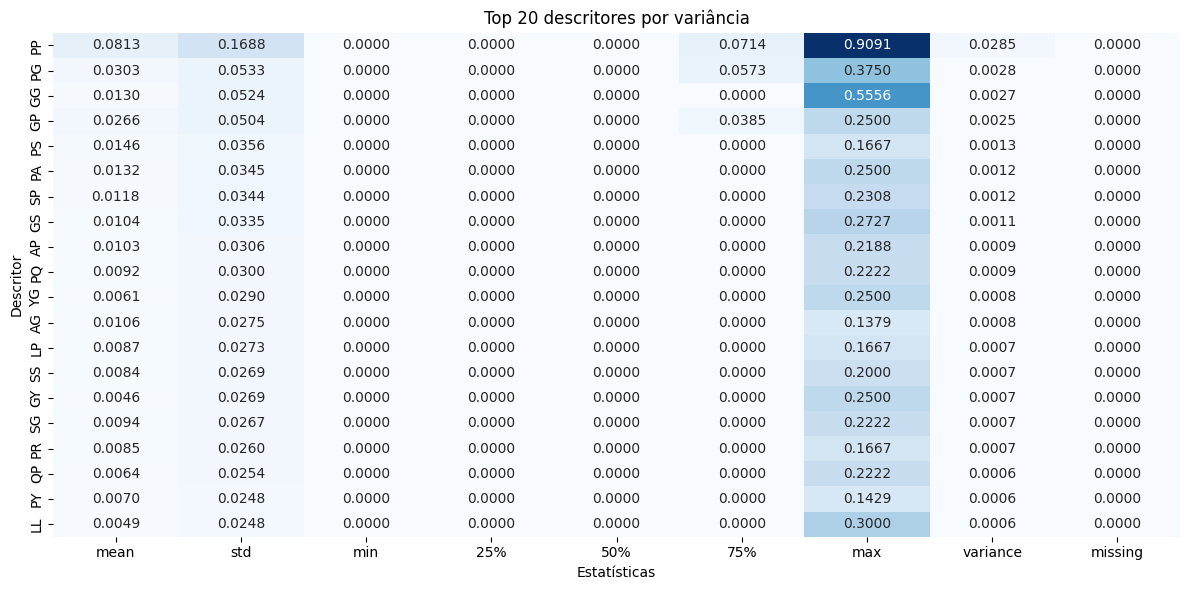

In [36]:
top20_stats = (
    estatisticas
    .drop(columns=["count"])
    .sort_values("variance", ascending=False)
    .head(20)
)

# ============================================================
# Plotando como tabela
# ============================================================
plt.figure(figsize=(12,6))
sns.heatmap(
    top20_stats,
    annot=True,
    fmt=".4f",
    cmap="Blues",
    cbar=False
)
plt.title("Top 20 descritores por variância")
plt.xlabel("Estatísticas")
plt.ylabel("Descritor")
plt.tight_layout()
plt.show()


A variância é utilizada para identificar quais pares de aminoácidos apresentam maior capacidade de discriminar as sequências.

Descritores com variância muito baixa assumem valores semelhantes em praticamente todos os peptídeos e tendem a contribuir pouco para os modelos de Aprendizado de Máquina.

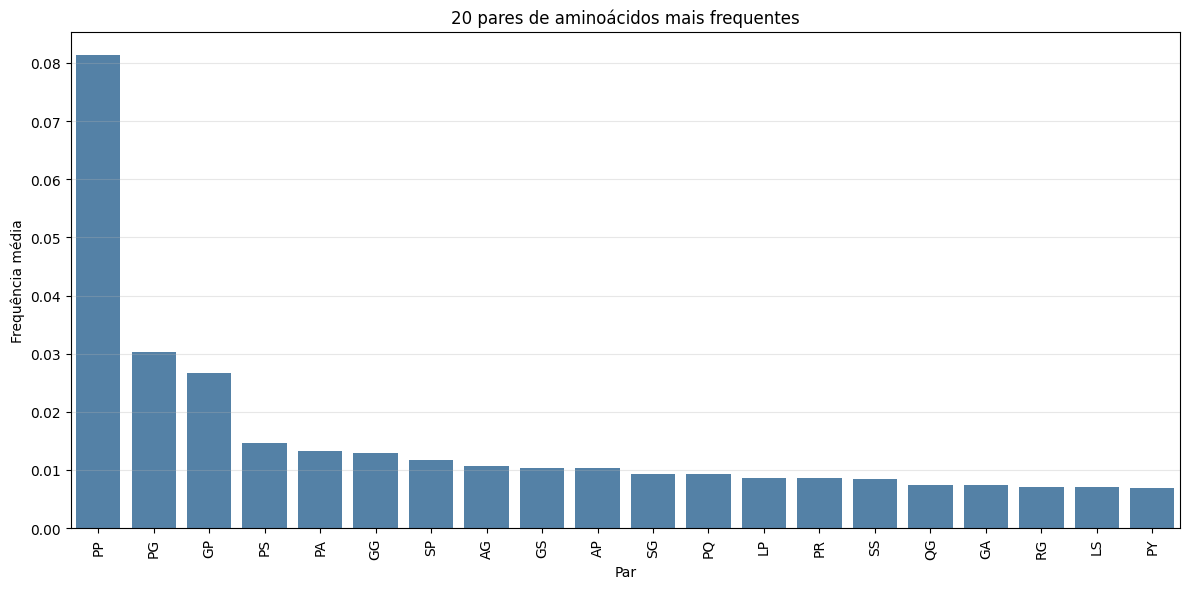

In [12]:
# Frequência média dos pares
media = (
    aal_only
    .mean()
    .sort_values(ascending=False)
)
top20 = media.head(20)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top20.index,
    y=top20.values,
    color="steelblue"
)
plt.xticks(rotation=90)
plt.title("20 pares de aminoácidos mais frequentes")
plt.xlabel("Par")
plt.ylabel("Frequência média")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

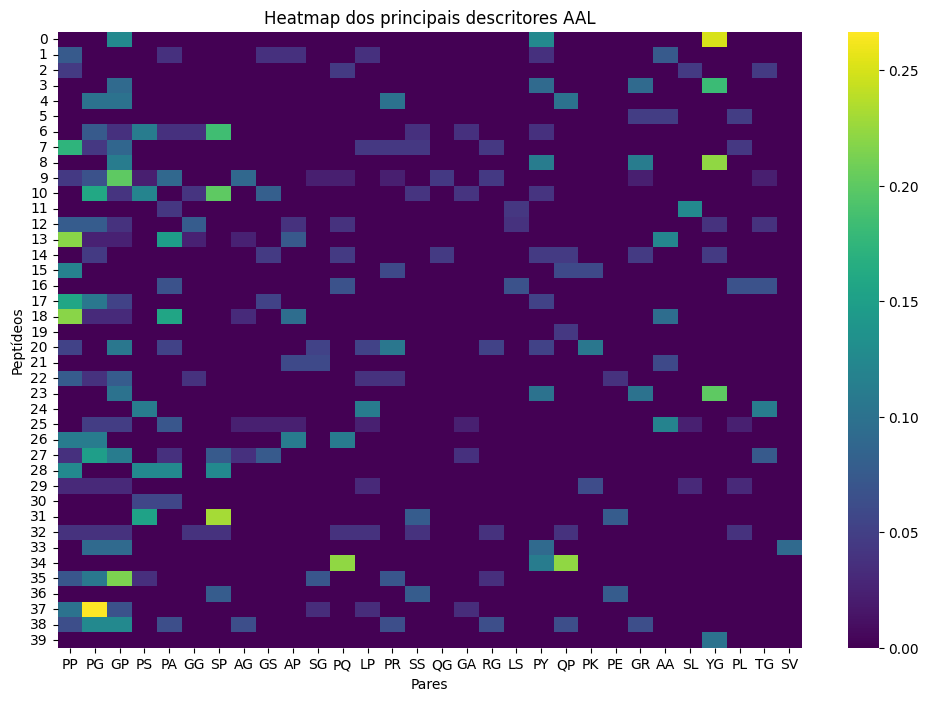

In [13]:
# Heatmap - Mostrar apenas os 30 mais frequentes
top30 = media.head(30).index
plt.figure(figsize=(12,8))
sns.heatmap(
    aal_only[top30].iloc[:40],
    cmap="viridis"
)
plt.title("Heatmap dos principais descritores AAL")
plt.xlabel("Pares")
plt.ylabel("Peptídeos")
plt.show()

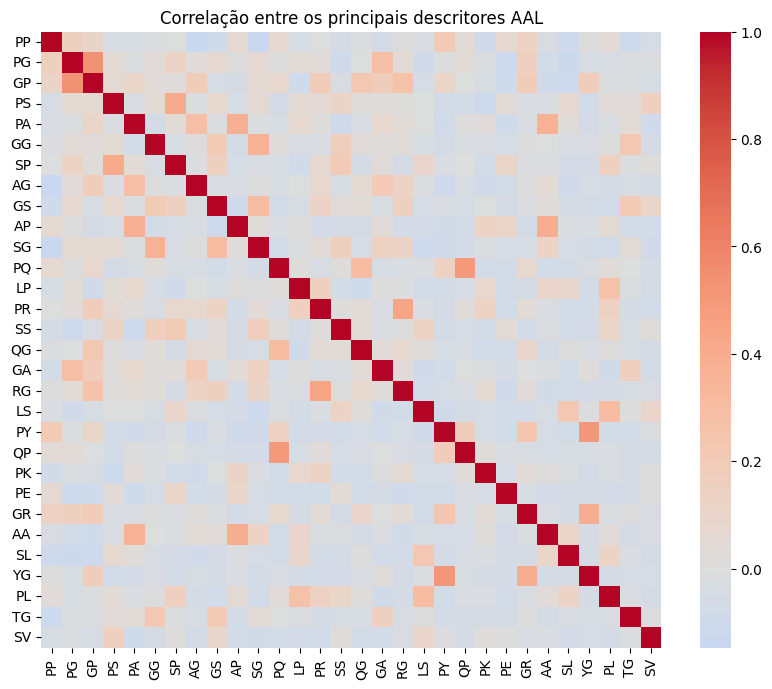

In [14]:
# Correlação entre atributos - Top 30
corr = aal_only[top30].corr()
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Correlação entre os principais descritores AAL")
plt.show()

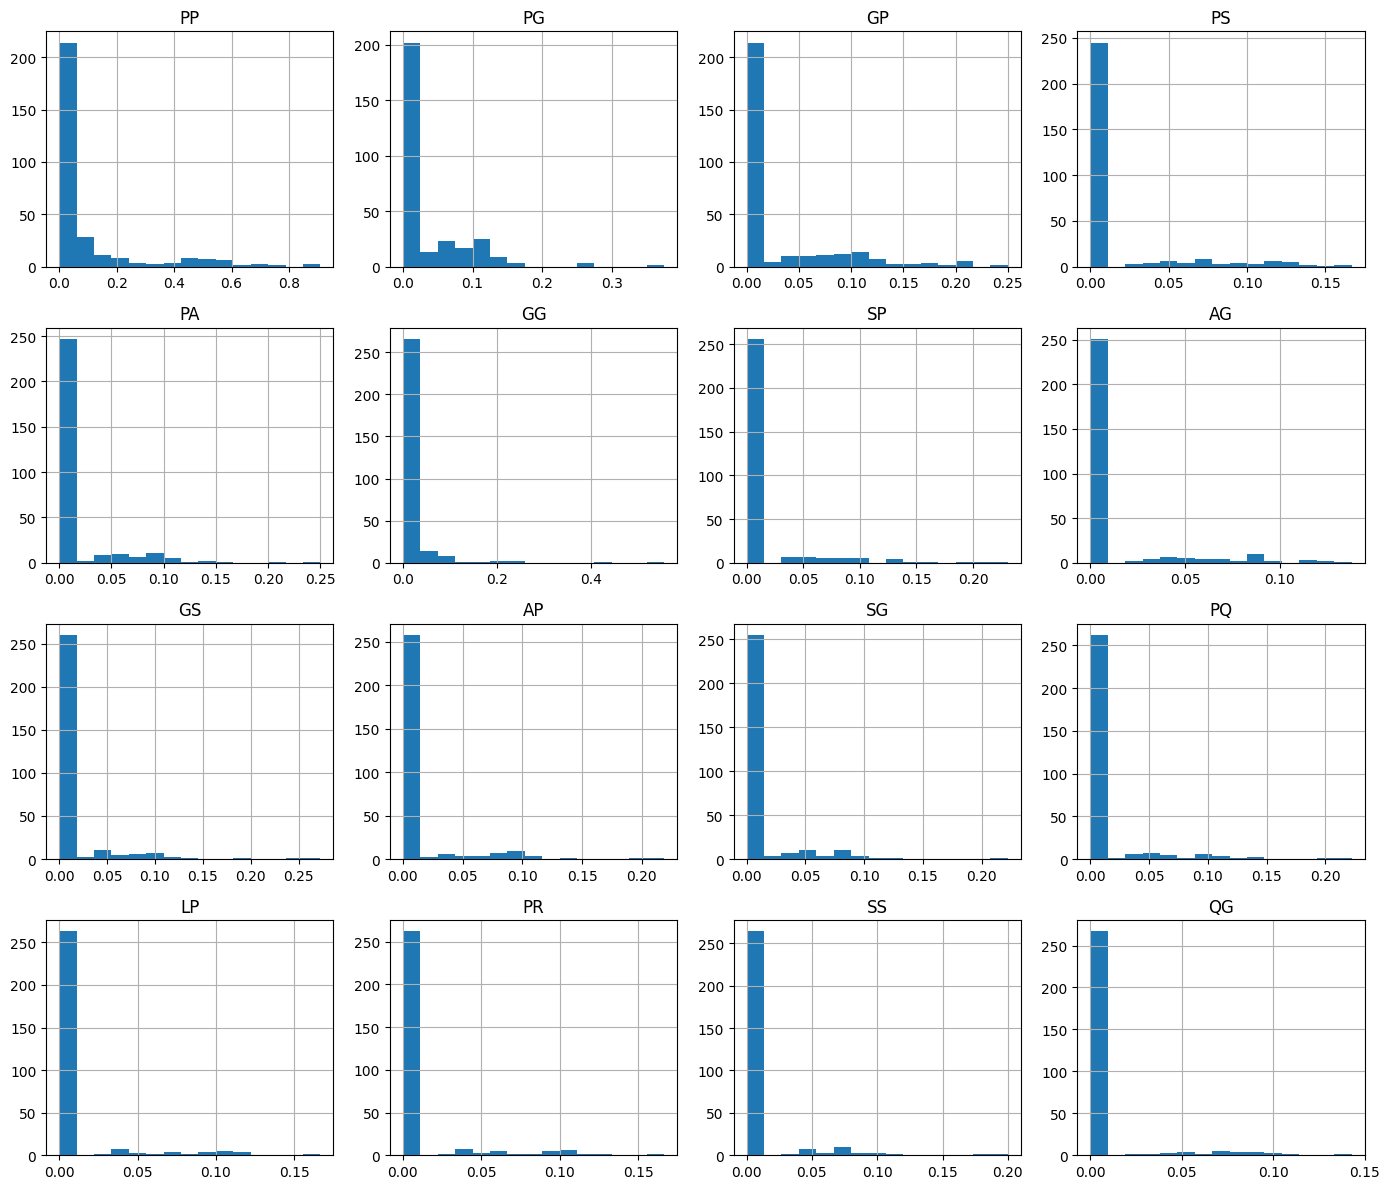

In [15]:
# Distribuição dos atributos - Selecionar apenas os 16 principais.
aal_only[top20.index[:16]].hist(
    figsize=(14,12),
    bins=15
)
plt.tight_layout()
plt.show()

In [16]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(aal_only)

pca_aal = PCA(n_components=2)

X_pca = pca_aal.fit_transform(X)

# Variância explicada
print(pca_aal.explained_variance_ratio_)

[0.01428582 0.01345089]


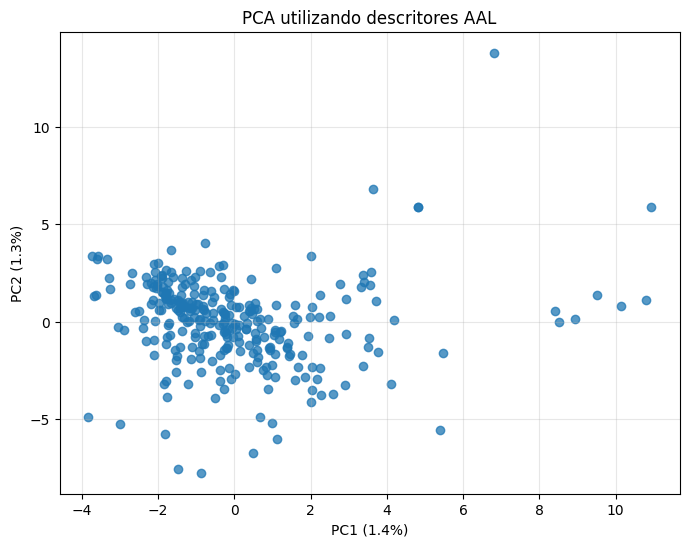

In [17]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.75
)
plt.title("PCA utilizando descritores AAL")
plt.xlabel(
    f"PC1 ({100*pca_aal.explained_variance_ratio_[0]:.1f}%)"
)
plt.ylabel(
    f"PC2 ({100*pca_aal.explained_variance_ratio_[1]:.1f}%)"
)
plt.grid(alpha=0.3)
plt.show()

In [18]:
# Salvar o objeto PCA
import pickle

with open("../data/processed/pca_aal.pkl", "wb") as f:
    pickle.dump(pca_aal, f)

In [19]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)
X_tsne = tsne.fit_transform(X)

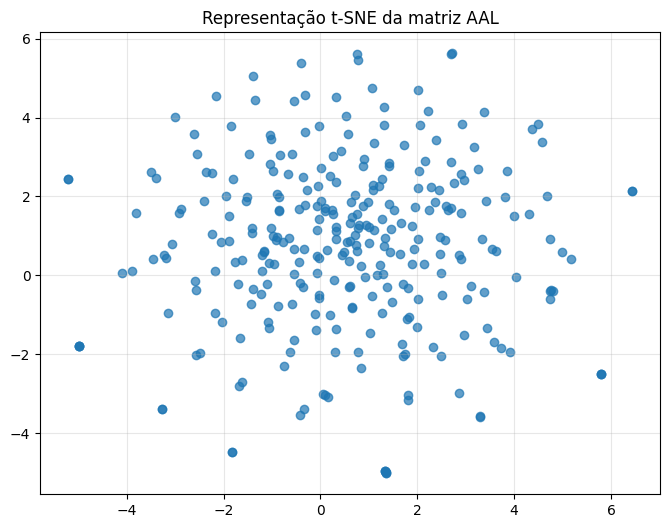

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.7
)
plt.title("Representação t-SNE da matriz AAL")
plt.grid(alpha=0.3)
plt.show()

In [21]:
# Correlação com o Docking
corr_target = (
    aal_df
    .corr(numeric_only=True)["best_docking_score"]
    .drop("best_docking_score")
)

# Top20 positivos
corr_target.nlargest(20)

GG    0.200393
LA    0.194269
AK    0.192809
TA    0.166805
EE    0.164754
DA    0.163218
KE    0.158062
SG    0.154218
LD    0.148606
KL    0.144934
VE    0.139609
VL    0.124445
RK    0.121361
TD    0.120973
DP    0.114263
KA    0.114169
AL    0.112026
VR    0.106436
ED    0.104265
KV    0.100350
Name: best_docking_score, dtype: float64

In [22]:
# Top20 negativos
corr_target.nsmallest(20)

GY   -0.278566
YG   -0.258040
GP   -0.246194
PY   -0.236921
RF   -0.210013
FG   -0.207588
GR   -0.183324
FA   -0.169506
SY   -0.159299
LW   -0.146686
WR   -0.146686
PF   -0.142717
SF   -0.142211
PG   -0.139998
CC   -0.135052
GH   -0.134866
WA   -0.134479
SP   -0.133618
FS   -0.132107
WI   -0.131897
Name: best_docking_score, dtype: float64

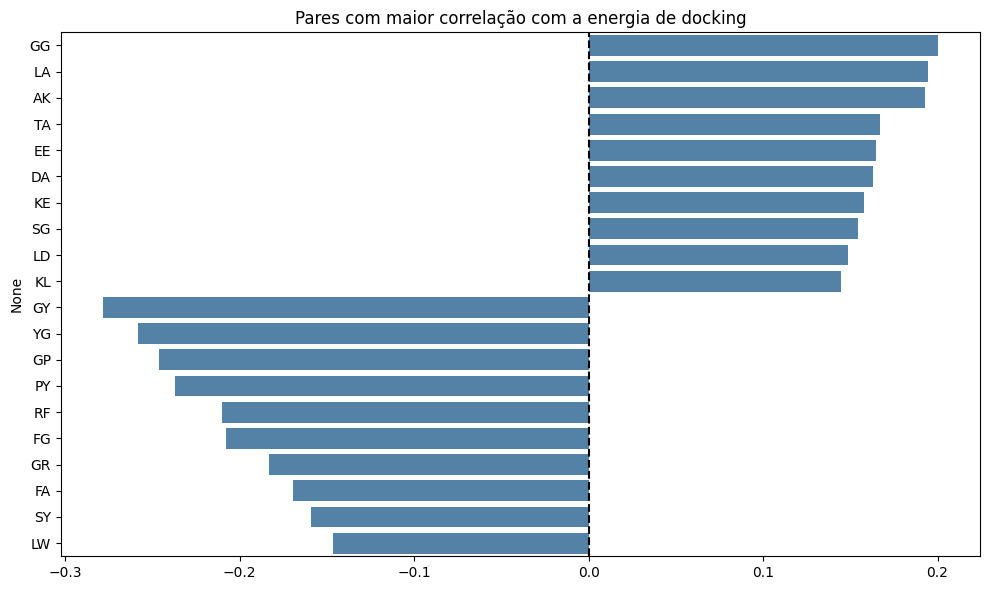

In [23]:
top = pd.concat([
    corr_target.nlargest(10),
    corr_target.nsmallest(10)
])

plt.figure(figsize=(10,6))
sns.barplot(
    x=top.values,
    y=top.index,
    color="steelblue"
)

plt.axvline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Pares com maior correlação com a energia de docking"
)

plt.tight_layout()
plt.show()

In [24]:
# Seleção de atributos
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    aal_only,
    aal_df["best_docking_score"],
    random_state=42
)

mi = pd.Series(
    mi,
    index=aal_only.columns
).sort_values(ascending=False)

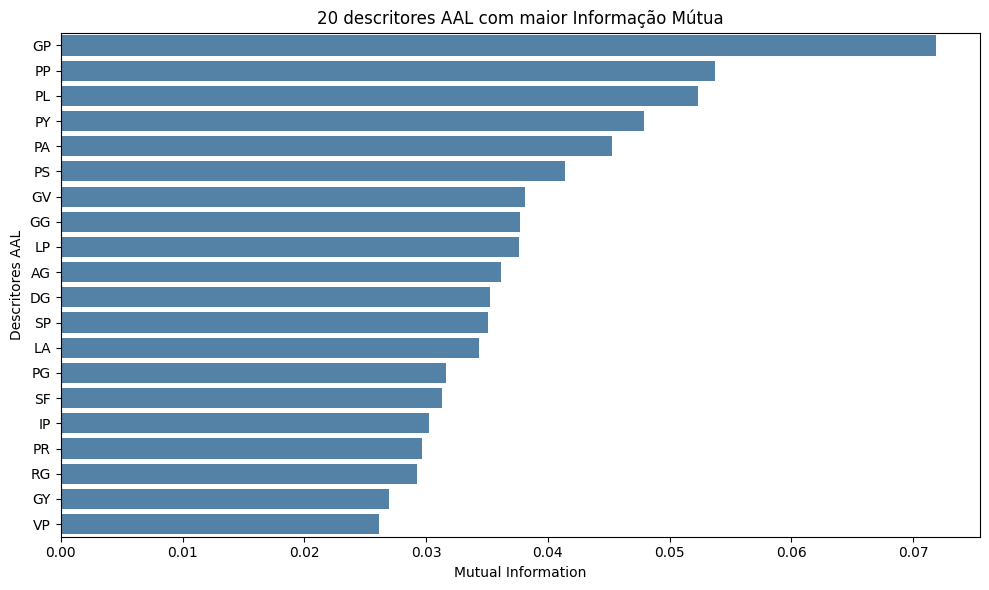

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=mi.head(20).values,
    y=mi.head(20).index,
    color="steelblue"
)

plt.title("20 descritores AAL com maior Informação Mútua")
plt.xlabel("Mutual Information")
plt.ylabel("Descritores AAL")
plt.tight_layout()
plt.show()

In [41]:
mi.head(10).to_frame("Mutual Information")

,Mutual Information
GP,0.071898
PP,0.053703
PL,0.052300
PY,0.047877
PA,0.045293
PS,0.041390
GV,0.038086
GG,0.037728
LP,0.037624
AG,0.036143


In [26]:
# Comparação entre AAC e AAL
import pickle

with open("../data/processed/pca_aac.pkl", "rb") as f:
    pca_aac = pickle.load(f)


aac_df = pd.read_csv("../data/processed/aac_features.csv")
aac_only = aac_df.drop(columns=["best_docking_score"])

comparacao = pd.DataFrame({

    "AAC":[
        aac_only.shape[1],
        aac_only.var().mean(),
        pca_aac.explained_variance_ratio_.sum()
    ],

    "AAL":[
        aal_only.shape[1],
        aal_only.var().mean(),
        pca_aal.explained_variance_ratio_.sum()
    ]

},

index=[
    "Número de atributos",
    "Variância média",
    "Variância explicada (PCA)"
])

comparacao

,AAC,AAL
Número de atributos,20.000000,400.000000
Variância média,0.005424,0.000270
Variância explicada (PCA),0.191438,0.027737


In [27]:
aal_df.to_csv(
    "../data/processed/aal_features.csv",
    index=False
)
print("Dataset AAL salvo com sucesso.")

Dataset AAL salvo com sucesso.


## Conclusões

Neste notebook foi implementado o descritor **Amino Acid Linking (AAL)**, responsável por representar cada peptídeo a partir da frequência relativa dos pares consecutivos de aminoácidos.

Diferentemente do descritor AAC, o AAL incorpora informações sobre a ordem local dos resíduos, preservando parte da organização da sequência biológica. Essa característica resulta em uma representação de maior dimensionalidade (400 atributos) e potencialmente mais informativa para tarefas de regressão.

As análises estatísticas mostraram que apenas uma parcela dos pares apresenta elevada variabilidade e maior associação com a energia de docking, indicando que técnicas de seleção de atributos poderão desempenhar papel importante nas etapas de modelagem.

Além disso, as projeções por PCA e t-SNE evidenciaram uma representação mais rica do espaço de características quando comparada ao AAC, embora ainda sem agrupamentos claramente definidos. Esses resultados reforçam que a organização local dos aminoácidos acrescenta informação relevante, mas ainda não captura completamente as relações estruturais existentes nas sequências.

No próximo notebook será implementado o descritor **CKSNAP**, que amplia essa representação ao considerar pares de aminoácidos separados por diferentes distâncias na sequência, incorporando informações de vizinhança que não são contempladas pelo AAL.